In [7]:
import zipfile
import os

zip_path = "/content/Eye_Disease.zip"
extract_path = "/content/Eye_Disease"

# Create extraction folder
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")
print("Files extracted to:", extract_path)
print("all ok")

Unzipped successfully!
Files extracted to: /content/Eye_Disease
all ok


In [8]:
import os

dataset_path = "/content/Eye_Disease/Original Dataset"

print(os.listdir(dataset_path))

['Glaucoma', 'Healthy', 'Retinal Detachment', 'Diabetic Retinopathy', 'Retinitis Pigmentosa', 'Central Serous Chorioretinopathy [Color Fundus]', 'Pterygium', 'Macular Scar', 'Disc Edema', 'Myopia']


In [11]:
import shutil

shutil.rmtree("/content/Eye_Disease/Original Dataset/Retinal Detachment", ignore_errors=True)
shutil.rmtree("/content/Eye_Disease/Original Dataset/Retinitis Pigmentosa", ignore_errors=True)
shutil.rmtree("/content/Eye_Disease/Original Dataset/Central Serous Chorioretinopathy [Color Fundus]", ignore_errors=True)
shutil.rmtree("/content/Eye_Disease/Original Dataset/Pterygium", ignore_errors=True)
shutil.rmtree("/content/Eye_Disease/Original Dataset/Disc Edema", ignore_errors=True)

print("Folder deleted successfully!")

Folder deleted successfully!


In [12]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Dataset path
dataset_path = "/content/Eye_Disease/Original Dataset"

# Output directories
train_dir = "/content/eye_disease_split/train"
test_dir = "/content/eye_disease_split/test"

classes = [d for d in os.listdir(dataset_path)
          if os.path.isdir(os.path.join(dataset_path, d))]

print(classes)

# Create train and test folders
for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

# Split ratio
test_size = 0.2  # 20% test, 80% train

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    images = [
        img for img in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, img))
    ]

    train_imgs, test_imgs = train_test_split(
        images,
        test_size=test_size,
        random_state=42,
        shuffle=True
    )

    # Copy train images
    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(train_dir, cls, img)
        )

    # Copy test images
    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(test_dir, cls, img)
        )

    print(f"{cls}:")
    print(f"  Train = {len(train_imgs)}")
    print(f"  Test  = {len(test_imgs)}")

print("\nDataset split completed!")

['Glaucoma', 'Healthy', 'Diabetic Retinopathy', 'Macular Scar', 'Myopia']
Glaucoma:
  Train = 1079
  Test  = 270
Healthy:
  Train = 819
  Test  = 205
Diabetic Retinopathy:
  Train = 1207
  Test  = 302
Macular Scar:
  Train = 355
  Test  = 89
Myopia:
  Train = 400
  Test  = 100

Dataset split completed!


In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Dataset paths
train_path = "/content/eye_disease_split/train"
test_path = "/content/eye_disease_split/test"

# Function to count images in each class
def count_images(folder_path):
    class_counts = {}

    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)

        if os.path.isdir(class_folder):
            count = len([
                f for f in os.listdir(class_folder)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            class_counts[class_name] = count

    return class_counts

# Count train and test images
train_counts = count_images(train_path)
test_counts = count_images(test_path)

# Convert to DataFrame
train_df = pd.DataFrame({
    "Class": list(train_counts.keys()),
    "Count": list(train_counts.values())
})

test_df = pd.DataFrame({
    "Class": list(test_counts.keys()),
    "Count": list(test_counts.values())
})

# Print counts
print("Train Class Counts:")
print(train_df)

print("\nTest Class Counts:")
print(test_df)

Train Class Counts:
                  Class  Count
0              Glaucoma   1079
1               Healthy    819
2  Diabetic Retinopathy   1207
3          Macular Scar    355
4                Myopia    400

Test Class Counts:
                  Class  Count
0              Glaucoma    270
1               Healthy    205
2  Diabetic Retinopathy    302
3          Macular Scar     89
4                Myopia    100


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, BatchNormalization, ReLU, Activation,
    Add, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout,
    Multiply, Reshape, Lambda
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [15]:
# =============================================================
# DATASET PATHS
# =============================================================
train_dir = "/content/eye_disease_split/train"
test_dir  = "/content/eye_disease_split/test"

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

In [16]:
# =============================================================
# DATA GENERATORS — Strong augmentation for medical images
# =============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,          # brain MRIs can be slightly rotated
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],  # MRI contrast variation
    shear_range=0.05
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
print(f"Classes: {train_data.class_indices}")
print(f"Train batches: {len(train_data)} | Test batches: {len(test_data)}")

Found 3860 images belonging to 5 classes.
Found 966 images belonging to 5 classes.
Classes: {'Diabetic Retinopathy': 0, 'Glaucoma': 1, 'Healthy': 2, 'Macular Scar': 3, 'Myopia': 4}
Train batches: 121 | Test batches: 31


In [17]:
# =============================================================
# BUILDING BLOCKS
# =============================================================

def depthwise_sep_conv(x, filters, stride=1):
    """
    Depthwise Separable Convolution block.
    ~8x fewer parameters than standard Conv2D of the same filter size.
    """
    x = DepthwiseConv2D(3, strides=stride, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(filters, 1, padding='same', use_bias=False)(x)  # pointwise
    x = BatchNormalization()(x)
    x = ReLU()(x)
    return x


def se_block(x, ratio=8):
    """
    Squeeze-and-Excitation block.
    Learns channel-wise attention: which feature maps are important.
    ratio=8 keeps parameter overhead tiny (~2*C^2/ratio params).
    """
    channels = x.shape[-1]
    # Squeeze: global context
    se = GlobalAveragePooling2D()(x)
    se = Reshape((1, 1, channels))(se)
    # Excitation: learn to re-weight channels
    se = Conv2D(max(channels // ratio, 4), 1, activation='relu', use_bias=False)(se)
    se = Conv2D(channels, 1, activation='sigmoid', use_bias=False)(se)
    # Scale
    return Multiply()([x, se])


def residual_ds_block(x, filters, downsample=False):
    """
    Residual block using Depthwise Separable Convolutions + SE attention.
    If channel count changes or spatial dims change, uses a 1x1 projection shortcut.
    """
    stride = 2 if downsample else 1
    shortcut = x

    # Main path
    x = depthwise_sep_conv(x, filters, stride=stride)
    x = depthwise_sep_conv(x, filters, stride=1)
    x = se_block(x)  # channel attention

    # Projection shortcut if needed
    if downsample or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

In [18]:
# =============================================================
# MODEL ARCHITECTURE
# =============================================================
# Design rationale:
# - Stem: standard conv (preserves early low-level texture details)
# - Stage 1-4: Residual DS blocks with SE attention
# - Progressive widening: 32→64→128→256 channels
# - Stages 2,3,4 downsample spatially (stride=2), keeping compute manageable
# - Head: GAP (removes spatial dims) + single 256-unit Dense + output
#
# Total estimated params: ~1.1–1.4M (vs VGG16's 6.5M)
# =============================================================

def build_model(num_classes, input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)

    # --- STEM ---
    # Standard 3x3 conv first: captures raw low-level MRI textures
    x = Conv2D(32, 3, strides=2, padding='same', use_bias=False)(inputs)  # 112x112
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D(2)(x)  # 56x56

    # --- STAGE 1 — 64 channels ---
    x = residual_ds_block(x, 64, downsample=False)  # 56x56
    x = residual_ds_block(x, 64, downsample=False)  # 56x56

    # --- STAGE 2 — 128 channels ---
    x = residual_ds_block(x, 128, downsample=True)  # 28x28
    x = residual_ds_block(x, 128, downsample=False) # 28x28
    x = residual_ds_block(x, 128, downsample=False) # 28x28

    # --- STAGE 3 — 256 channels ---
    x = residual_ds_block(x, 256, downsample=True)  # 14x14
    x = residual_ds_block(x, 256, downsample=False) # 14x14
    x = residual_ds_block(x, 256, downsample=False) # 14x14

    # --- STAGE 4 — 512 channels (optional, comment out to save params) ---
    # Uncomment if you want more capacity (~+500K params):
    # x = residual_ds_block(x, 512, downsample=True)  # 7x7
    # x = residual_ds_block(x, 512, downsample=False) # 7x7

    # --- HEAD ---
    x = GlobalAveragePooling2D()(x)  # replaces Flatten — much more efficient
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='EfficientBrainNet')
    return model


model = build_model(NUM_CLASSES)
model.summary()

Model: "EfficientBrainNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │      9,216 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 56, 56,    │        288 │ max_pooling2d[0]… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │      2,048 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 56, 56,    │        576 │ re_lu_3[0][0]     │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat

 Total params: 691,205 (2.64 MB)

 Trainable params: 680,389 (2.60 MB)

 Non-trainable params: 10,816 (42.25 KB)

In [19]:
# =============================================================
# COMPILE
# =============================================================
# Label smoothing: reduces overconfidence, improves generalization
# Particularly helpful for medical datasets where boundary cases exist

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [20]:
# =============================================================
# CALLBACKS
# =============================================================
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',  # watch accuracy, not just loss
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_eye_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [21]:
# =============================================================
# TRAINING — Phase 1: Warm up
# =============================================================
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3891 - loss: 1.6567
Epoch 1: val_accuracy improved from None to 0.29607, saving model to best_eye_model.keras

Epoch 1: finished saving model to best_eye_model.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.4337 - loss: 1.5249 - val_accuracy: 0.2961 - val_loss: 1.5749 - learning_rate: 0.0010
Epoch 2/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 870ms/step - accuracy: 0.5391 - loss: 1.3301
Epoch 2: val_accuracy did not improve from 0.29607
121/121 ━━━━━━━━━━━━━━━━━━━━ 120s 995ms/step - accuracy: 0.5409 - loss: 1.3321 - val_accuracy: 0.2122 - val_loss: 1.6479 - learning_rate: 0.0010
Epoch 3/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - accuracy: 0.5683 - loss: 1.2653
Epoch 3: val_accuracy did not improve from 0.29607
121/121 ━━━━━━━━━━━━━━━━━━━━ 121s 997ms/step - accuracy: 0.5847 - loss: 1.2435 - val_accuracy: 0.2122 - val_loss: 1.8217 - learning_rate: 0.0010
Epoch 4/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - acc

In [ ]:
# =============================================================
# FINE-TUNE — Phase 2: Lower LR for final squeeze
# If Phase 1 accuracy < 96%, run this cell to fine-tune
# =============================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

fine_tune_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_brain_model_finetuned.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_ft = model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=fine_tune_callbacks
)

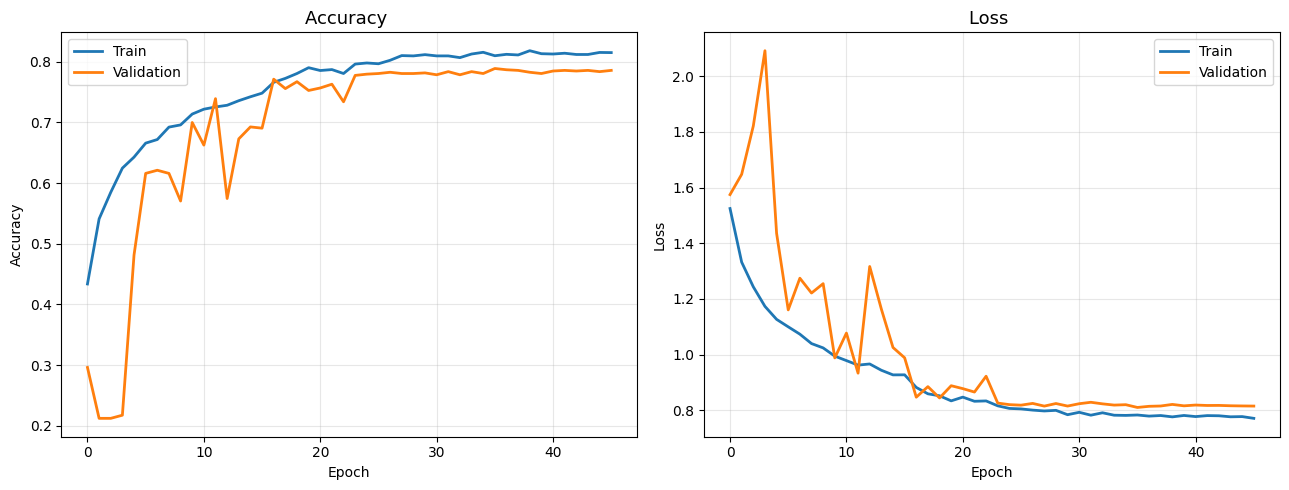

In [22]:
# =============================================================
# TRAINING CURVES
# =============================================================
def plot_history(h, title_suffix=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(h.history['accuracy'],     label='Train', linewidth=2)
    axes[0].plot(h.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0].set_title(f'Accuracy {title_suffix}', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(h.history['loss'],     label='Train', linewidth=2)
    axes[1].plot(h.history['val_loss'], label='Validation', linewidth=2)
    axes[1].set_title(f'Loss {title_suffix}', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history, '')
# plot_history(history_ft, '— Phase 2 Fine-tune')  # uncomment if you ran phase 2

31/31 ━━━━━━━━━━━━━━━━━━━━ 25s 652ms/step


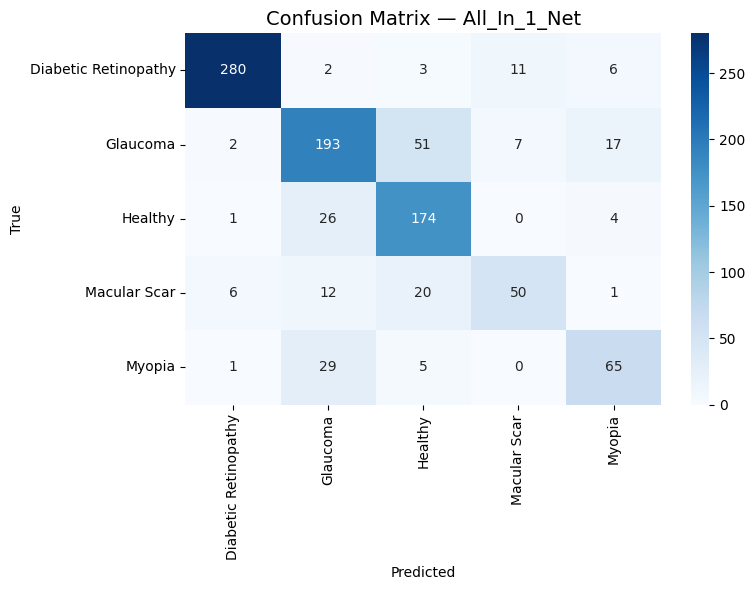


CLASSIFICATION REPORT
                      precision    recall  f1-score   support

Diabetic Retinopathy       0.97      0.93      0.95       302
            Glaucoma       0.74      0.71      0.73       270
             Healthy       0.69      0.85      0.76       205
        Macular Scar       0.74      0.56      0.64        89
              Myopia       0.70      0.65      0.67       100

            accuracy                           0.79       966
           macro avg       0.76      0.74      0.75       966
        weighted avg       0.79      0.79      0.79       966


>>> Final Test Accuracy: 78.88%
>>> Model Parameters: 691,205


In [23]:
# =============================================================
# EVALUATION
# =============================================================
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_probs = model.predict(test_data, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_data.classes
class_names  = list(test_data.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — All_In_1_Net', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))

# Overall accuracy
test_loss, test_acc = model.evaluate(test_data, verbose=0)
print(f"\n>>> Final Test Accuracy: {test_acc*100:.2f}%")
print(f">>> Model Parameters: {model.count_params():,}")

{0: 'Diabetic Retinopathy', 1: 'Glaucoma', 2: 'Healthy', 3: 'Macular Scar', 4: 'Myopia'}


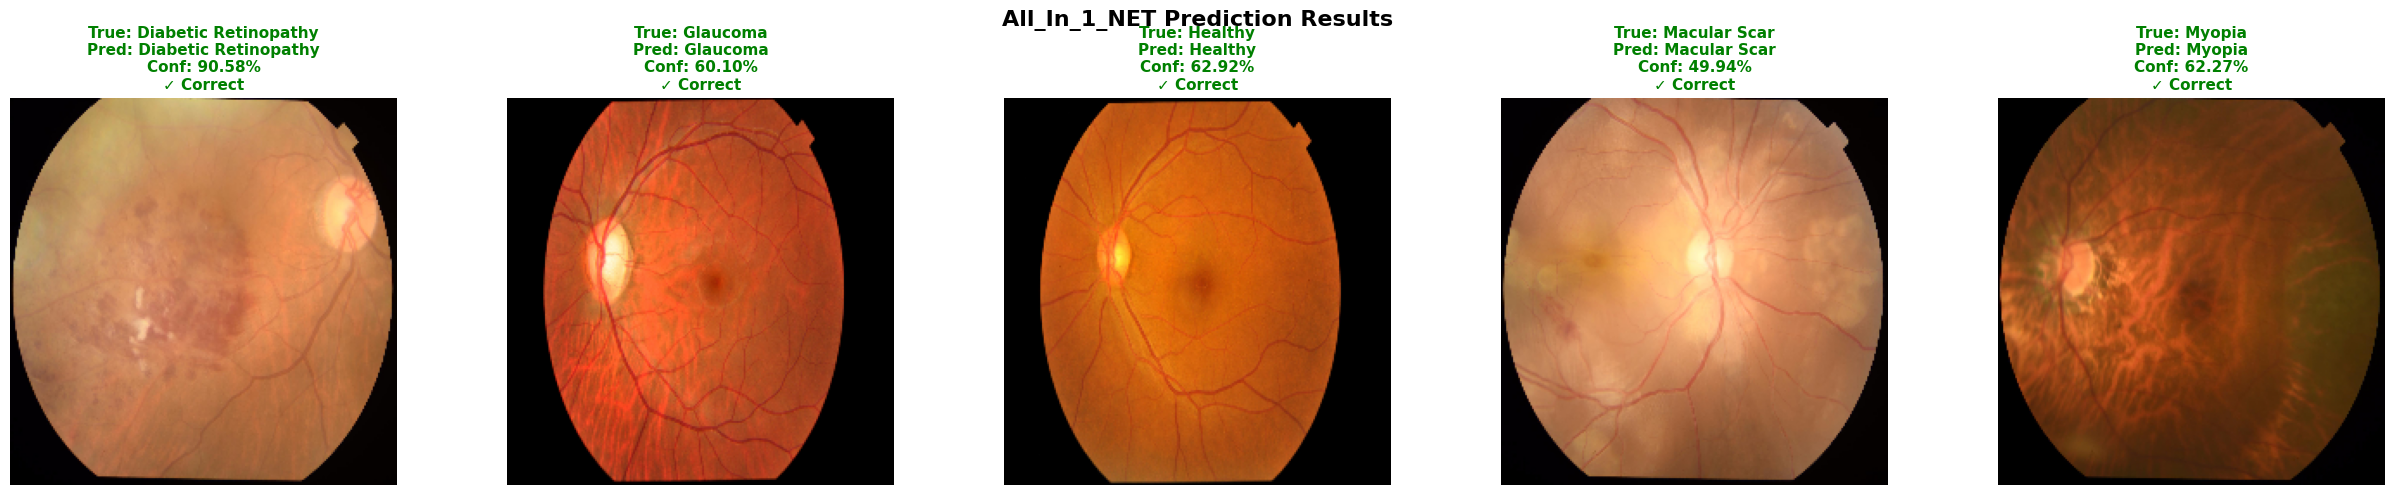

Saved -> prediction_results.png


In [24]:
# =============================================================
# ONE IMAGE PER CLASS - PREDICTION VISUALIZATION
# =============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as kimage

# -------------------------------------------------------------
# CLASS MAPPING
# -------------------------------------------------------------

class_indices = test_data.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

print(idx_to_class)

# -------------------------------------------------------------
# PICK ONE RANDOM IMAGE FROM EACH CLASS
# -------------------------------------------------------------

selected_images = {}

random.seed(42)

for cls in class_names:

    cls_dir = os.path.join(test_dir, cls)

    files = [
        os.path.join(cls_dir, f)
        for f in os.listdir(cls_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    selected_images[cls] = random.choice(files)

# -------------------------------------------------------------
# PLOT
# -------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    len(class_names),
    figsize=(5 * len(class_names), 5)
)

if len(class_names) == 1:
    axes = [axes]

for ax, (true_class, img_path) in zip(axes, selected_images.items()):

    # Load image
    img = kimage.load_img(img_path, target_size=(224, 224))
    img_array = kimage.img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    # Prediction
    preds = model.predict(img_input, verbose=0)

    pred_idx = np.argmax(preds[0])
    pred_class = idx_to_class[pred_idx]
    confidence = preds[0][pred_idx] * 100

    correct = (true_class == pred_class)

    # Display image
    ax.imshow(img)
    ax.axis("off")

    ax.set_title(
        f"True: {true_class}\n"
        f"Pred: {pred_class}\n"
        f"Conf: {confidence:.2f}%\n"
        f"{'✓ Correct' if correct else '✗ Wrong'}",
        fontsize=11,
        color="green" if correct else "red",
        fontweight="bold"
    )

plt.suptitle(
    "All_In_1_NET Prediction Results",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "prediction_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved -> prediction_results.png")

In [25]:
from google.colab import files

files.download('/content/best_eye_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>